# LOGISTIC REGRESSION

Linjär regression
Kan hantera kategoriska features

Logistisk regression 
Kan hantera kategoriska features OCH målvariabler
Kategoriska "FEATURES" måste ha en klassificeringsalgoritm

Categorical features require encoding

Kokchun rekommenderar dummy encoding vid större dataset

## Accuracy
1. True positive (TP) 1-1
2. False negative (FN) 1-0
3. False positive (FP) 0-1
4. True negative (TN) 0-0

ACCURACY = *TP + *TN / totala antalet förekomster

Detta är dåligt för "obalanserade dataset"

## Precision

PRECISION = *TP / *TP + *FP

Bra när vi har låg tolerans för false positive

# Recall

RECALL = *TP / *TP + *FN

# F1

2 x (prec x rev) / (prec + rec)

## Multinomial logistic regression for many classes



Exempel (blommor):
Iris 0
Versicolor 1
Virginica 2

0    1    2
0.7  0.1  0.2
0.1  0.8  0.1
0.2  0.6  0.2
0    0.1  0.9

In [13]:
import pandas as pd

df = pd.read_csv('../../data/Default.csv')

df.head(10)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879
5,No,Yes,919.588530,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451344
8,No,No,1161.057854,37468.529288
9,No,No,0.000000,29275.268293


In [16]:
import duckdb as db

query = db.query (
    """
    SELECT
        AVG(income) AS avg_income,
        student
    FROM
        df
    GROUP BY 
        2

"""
).df()

query

,avg_income,student
0,17950.230775,Yes
1,40011.952857,No


<Axes: xlabel='balance', ylabel='income'>

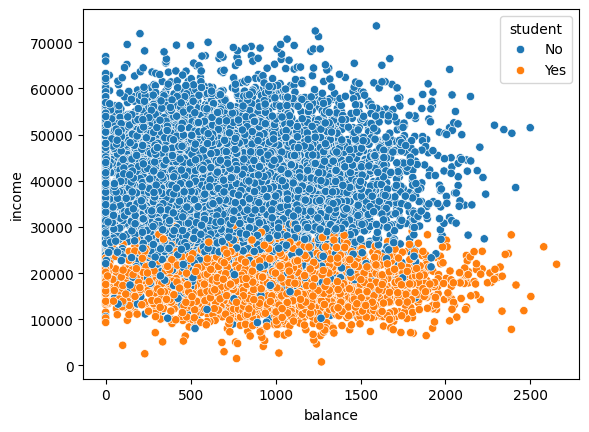

In [19]:
import seaborn as sns

sns.scatterplot(data=df, x='balance', y='income', hue='student')

<Axes: xlabel='default', ylabel='balance'>

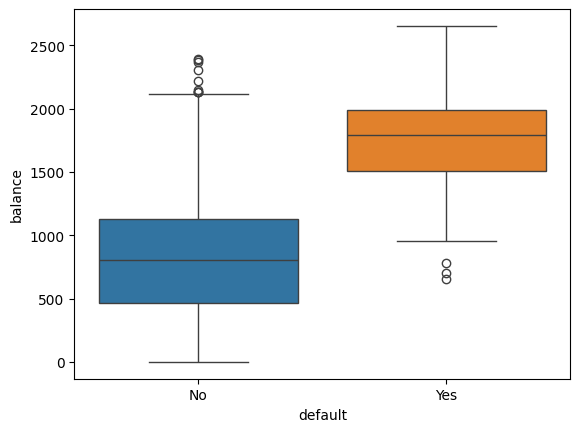

In [21]:
sns.boxplot(data=df, x='default', y='balance', hue='default')

## DUMMY ENCODING


In [39]:
# one hot encoding
df_one_hot_encoded = pd.get_dummies(df)
df_dummy_encoded = pd.get_dummies(df, drop_first=True)*1

In [24]:
df

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879
...,...,...,...,...
9995,No,No,711.555020,52992.378914
9996,No,No,757.962918,19660.721768
9997,No,No,845.411989,58636.156984
9998,No,No,1569.009053,36669.112365


In [25]:
df_one_hot_encoded

,balance,income,default_No,default_Yes,student_No,student_Yes
0,729.526495,44361.625074,True,False,True,False
1,817.180407,12106.134700,True,False,False,True
2,1073.549164,31767.138947,True,False,True,False
3,529.250605,35704.493935,True,False,True,False
4,785.655883,38463.495879,True,False,True,False
...,...,...,...,...,...,...
9995,711.555020,52992.378914,True,False,True,False
9996,757.962918,19660.721768,True,False,True,False
9997,845.411989,58636.156984,True,False,True,False
9998,1569.009053,36669.112365,True,False,True,False


In [40]:
df_dummy_encoded

,balance,income,default_Yes,student_Yes
0,729.526495,44361.625074,0,0
1,817.180407,12106.134700,0,1
2,1073.549164,31767.138947,0,0
3,529.250605,35704.493935,0,0
4,785.655883,38463.495879,0,0
...,...,...,...,...
9995,711.555020,52992.378914,0,0
9996,757.962918,19660.721768,0,0
9997,845.411989,58636.156984,0,0
9998,1569.009053,36669.112365,0,0


# Logistic regression

In [ ]:
# train test split

X, y = df_dummy_encoded.drop("default_Yes", axis=1), df_dummy_encoded["default_Yes"]

In [30]:
from sklearn.model_selection import train_test_split

help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None
)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape

(6700, 3)

In [38]:
print(f" Proportion default in training data: {y_train.sum() / len(X_train):.3f}")
print(f" Proportion default in training data: {y_test.sum() / len(X_test):.3f}")

 Proportion default in training data: 0.033
 Proportion default in training data: 0.033


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

print(f"{scaled_X_train.mean() = }")
print(f"{scaled_X_train.std() = }")
print(f"{scaled_X_test.mean() = }")
print(f"{scaled_X_test.std() = }")

scaled_X_train.mean() = np.float64(7.830110247306577e-17)
scaled_X_train.std() = np.float64(1.0)
scaled_X_test.mean() = np.float64(-0.0054675735434032815)
scaled_X_test.std() = np.float64(0.9870951848219804)


In [45]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(scaled_X_train, y_train)
model.coef_

array([[ 2.83066218,  0.0095274 , -0.27466992]])

TEST - Classify two samples

In [52]:
test_samples = pd.DataFrame({"balance": [1500, 1500], "income": [39200, 40000], "student_Yes": [1, 0]})

scaled_test_samples = scaler.transform(test_samples)
scaled_test_samples

array([[ 1.37268368,  0.4163719 ,  1.54286221],
       [ 1.37268368,  0.47593334, -0.64814602]])

In [54]:
model.predict_proba(scaled_test_samples)

array([[0.94282422, 0.05717578],
       [0.90028345, 0.09971655]])

In [58]:
# predict on all test data
y_pred = model.predict(scaled_X_test)
y_pred_proba = model.predict_proba(scaled_X_test)

y_pred

array([False, False, False, ..., False,  True, False], shape=(3300,))

# Evaluate

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, y_pred)

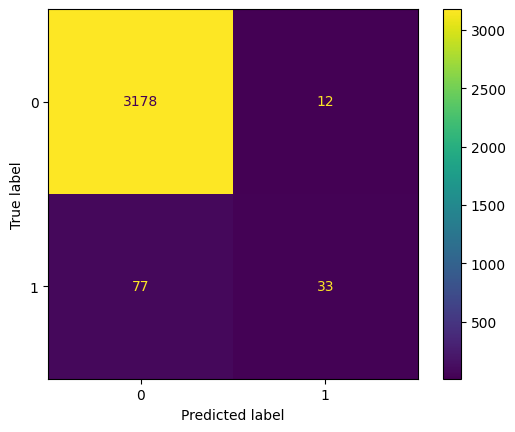

In [63]:
ConfusionMatrixDisplay(cm).plot()

In [72]:
TP = 33
TN = 3178
FP = 12
FN = 77

accuracy = (TP+TN) / (TP+TN+FP+FN)
print(f"Accuracy: {accuracy*100:.0f}%")

precision = TP / (TP+FP)
print(f"Precision: {precision*100:.0f}%")

recall = TP/(TP+FN)
print(f"Recall: {recall*100:.0f}%")

Accuracy: 97%
Precision: 73%
Recall: 30%


In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99      3190
        True       0.73      0.30      0.43       110

    accuracy                           0.97      3300
   macro avg       0.85      0.65      0.71      3300
weighted avg       0.97      0.97      0.97      3300

